# DS 4320 Project 2 — Solution Pipeline
## Do Geographically Western Teams Perform Better in the NCAA West Region?

**Author:** Kieran Perdue  
**Notebook:** `05_pipeline.ipynb`  
**Database:** `ncaab_west_region` (MongoDB Atlas)

### Research Question
*Do teams located significantly further west than their opponent win more often — and by larger margins — in NCAA Tournament West Region games, after controlling for team quality and seeding?*

### Pipeline Overview
1. **Load** West Region game documents from MongoDB Atlas into a pandas DataFrame
2. **Explore** the data — distributions, venue locations, longitude patterns
3. **Engineer features** — longitude difference as the focal variable, team quality as controls
4. **Model A** — baseline using team quality only (barthag_diff, seed_diff)
5. **Model B** — team quality + longitude difference
6. **Compare** — does adding geography improve prediction? (directly tests the hypothesis)
7. **Visualize** — publication-quality charts answering the research question


## 1. Setup

Imports, logging, and configuration. Set `MONGO_URI` as an environment variable before launching Jupyter — never hardcode credentials in the notebook:
```bash
export MONGO_URI="mongodb+srv://<user>:<pass>@<cluster>.mongodb.net/"
```

In [1]:
pip install mongo

In [3]:
import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pymongo import MongoClient
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, log_loss, roc_auc_score, brier_score_loss, roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_score

# ── Logging ───────────────────────────────────────────────────────────────────
Path("logs").mkdir(exist_ok=True)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler("logs/pipeline.log", mode="w"),
        logging.StreamHandler(),
    ],
)
log = logging.getLogger("pipeline")
log.info("Pipeline started.")

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"]       = 110
plt.rcParams["savefig.dpi"]      = 200
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"]      = "DejaVu Sans"
WEST_BLUE  = "#1D3557"
WEST_RED   = "#E63946"
WEST_GOLD  = "#F4A261"
WEST_GREEN = "#2A9D8F"

# ── Config ────────────────────────────────────────────────────────────────────
MONGO_URI   = os.environ.get("MONGO_URI", "mongodb://localhost:27017")
DB_NAME     = "ncaab_west_region"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
Path("figures").mkdir(exist_ok=True)
log.info(f"DB: {DB_NAME} | Seed: {RANDOM_SEED}")


## 2. Data Preparation — Query MongoDB into a DataFrame

We use a MongoDB `$match + $project` aggregation pipeline to filter incomplete
documents and flatten the nested document structure on the server side before
pandas receives the data.

The key field is **`hypothesis.lon_diff`** (`winner_lon − loser_lon`):
- **Negative** → winner was further west than the loser
- **Positive** → winner was further east than the loser

If geography matters in the West Region, we expect negative `lon_diff` to
correlate with larger win margins.

If MongoDB is unreachable the notebook automatically falls back to synthetic
data so all downstream cells still run.


In [4]:
# Known West Region venue longitudes by year (for synthetic fallback)
WEST_VENUE_LONS = {
    2015: -81.66, 2016: -121.49, 2017: -111.89, 2018: -117.16,
    2019: -121.89, 2021: -86.16, 2022: -122.42, 2023: -115.14,
    2024: -118.24, 2025: -122.42,
}

# Real team home longitudes used in synthetic data generation
TEAM_LONS = {
    "Gonzaga": -117.40, "Arizona": -110.95, "Arizona State": -111.93,
    "UCLA": -118.45, "USC": -118.29, "Oregon": -123.07, "Utah": -111.84,
    "Nevada": -119.82, "UNLV": -115.14, "San Diego State": -117.07,
    "BYU": -111.66, "Colorado": -105.27, "Washington": -122.30,
    "Kansas": -95.26, "Duke": -78.94, "Kentucky": -84.50,
    "Michigan": -83.74, "Villanova": -75.34, "Texas": -97.73,
    "Texas Tech": -101.88, "Baylor": -97.11, "Houston": -95.34,
    "Florida": -82.35, "Alabama": -87.57, "Tennessee": -83.93,
    "Purdue": -86.91, "Ohio State": -83.03, "Iowa": -91.53,
    "UConn": -72.26, "Virginia": -78.51, "North Carolina": -79.05,
    "Xavier": -84.47, "Creighton": -96.01, "Marquette": -87.94,
}


def _make_synthetic_games(n_per_season=13, seed=RANDOM_SEED):
    # Generate realistic West Region game data for offline development.
    # Uses real team longitudes and embeds a weak but detectable geographic
    # signal matching what the literature suggests for home-region advantage.
    rng = np.random.default_rng(seed)
    seasons = [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
    teams   = list(TEAM_LONS.keys())
    rows = []
    for season in seasons:
        venue_lon = WEST_VENUE_LONS[season]
        for _ in range(n_per_season):
            ta, tb = rng.choice(teams, size=2, replace=False)
            lon_a, lon_b = TEAM_LONS[ta], TEAM_LONS[tb]
            q_a = rng.uniform(0.2, 0.95)
            q_b = rng.uniform(0.2, 0.95)
            lon_bonus = 0.3 * (lon_b - lon_a) / 100
            p_a = 1 / (1 + np.exp(-3*(q_a - q_b) - lon_bonus))
            a_wins = rng.random() < p_a
            wq, lq   = (q_a, q_b)   if a_wins else (q_b, q_a)
            wt, lt   = (ta, tb)     if a_wins else (tb, ta)
            wl, ll   = (lon_a, lon_b) if a_wins else (lon_b, lon_a)
            w_seed = int(np.clip(rng.normal(4 - wq*3, 2), 1, 16))
            l_seed = int(np.clip(rng.normal(4 - lq*3, 2), 1, 16))
            base   = 72
            w_pts  = int(np.clip(rng.normal(base+4, 7), 52, 110))
            l_pts  = int(np.clip(rng.normal(base-4, 7), 42, w_pts-1))
            rows.append({
                "season": season, "region": "West",
                "winner": wt, "loser": lt,
                "winner_pts": w_pts, "loser_pts": l_pts,
                "winner_seed": w_seed, "loser_seed": l_seed,
                "point_diff": w_pts - l_pts,
                "venue_lon": venue_lon,
                "winner_lon": wl, "loser_lon": ll,
                "lon_diff": wl - ll,
                "winner_dist_miles": abs(wl - venue_lon) * 54.6,
                "loser_dist_miles":  abs(ll - venue_lon) * 54.6,
                "dist_diff_miles":  (abs(wl-venue_lon) - abs(ll-venue_lon)) * 54.6,
                "seed_diff": w_seed - l_seed,
                "winner_barthag": float(np.clip(rng.normal(0.5+wq*0.4, 0.1), 0.05, 0.99)),
                "loser_barthag":  float(np.clip(rng.normal(0.5+lq*0.4, 0.1), 0.05, 0.99)),
                "winner_adjoe": rng.normal(105 + wq*15, 3),
                "loser_adjoe":  rng.normal(105 + lq*15, 3),
                "winner_adjde": rng.normal(102 - wq*12, 3),
                "loser_adjde":  rng.normal(102 - lq*12, 3),
            })
    df = pd.DataFrame(rows)
    df["barthag_diff"] = df["winner_barthag"] - df["loser_barthag"]
    df["adjoe_diff"]   = df["winner_adjoe"]   - df["loser_adjoe"]
    df["adjde_diff"]   = df["winner_adjde"]   - df["loser_adjde"]
    log.info(f"Generated {len(df)} synthetic West Region games.")
    return df


def load_games_from_mongo(uri=MONGO_URI, db_name=DB_NAME):
    # Connect to MongoDB Atlas and flatten nested game documents into a DataFrame.
    # Falls back to synthetic data if Atlas is unreachable so all cells run.
    try:
        client = MongoClient(uri, serverSelectionTimeoutMS=8_000)
        client.admin.command("ping")
        log.info("Connected to MongoDB Atlas.")
    except Exception as e:
        log.warning(f"MongoDB unreachable ({type(e).__name__}) — using synthetic data.")
        return _make_synthetic_games()

    pipeline = [
        {"$match": {
            "winner.lon":             {"$ne": None},
            "loser.lon":              {"$ne": None},
            "winner.ratings.barthag": {"$ne": None},
            "loser.ratings.barthag":  {"$ne": None},
        }},
        {"$project": {
            "_id": 0, "season": 1, "region": 1,
            "winner": "$winner.team",  "loser": "$loser.team",
            "winner_pts": "$winner.pts", "loser_pts": "$loser.pts",
            "winner_seed": "$winner.seed", "loser_seed": "$loser.seed",
            "winner_lon": "$winner.lon",   "loser_lon": "$loser.lon",
            "venue_lon":  "$venue.lon",
            "lon_diff":          "$hypothesis.lon_diff",
            "dist_diff_miles":   "$hypothesis.dist_diff_miles",
            "winner_dist_miles": "$winner.dist_miles",
            "loser_dist_miles":  "$loser.dist_miles",
            "barthag_diff":  "$hypothesis.barthag_diff",
            "adjoe_diff":    "$hypothesis.adjoe_diff",
            "adjde_diff":    "$hypothesis.adjde_diff",
            "seed_diff":     "$hypothesis.seed_diff",
            "winner_barthag": "$winner.ratings.barthag",
            "loser_barthag":  "$loser.ratings.barthag",
            "winner_adjoe":   "$winner.ratings.adjoe",
            "loser_adjoe":    "$loser.ratings.adjoe",
            "winner_adjde":   "$winner.ratings.adjde",
            "loser_adjde":    "$loser.ratings.adjde",
        }},
    ]
    try:
        docs = list(client[db_name].games.aggregate(pipeline))
    except Exception as e:
        log.error(f"Aggregation failed: {e}")
        raise
    finally:
        client.close()
    df = pd.DataFrame(docs)
    df["point_diff"] = df["winner_pts"] - df["loser_pts"]
    log.info(f"Pulled {len(df):,} documents from MongoDB.")
    return df


games = load_games_from_mongo()
print(f"Games loaded : {len(games):,}")
print(f"Seasons      : {sorted(games['season'].unique())}")
print(f"lon_diff range: {games['lon_diff'].min():.1f} to {games['lon_diff'].max():.1f} degrees")
games.head()


Games loaded : 76
Seasons      : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
lon_diff range: -51.3 to 37.5 degrees


,season,region,winner,loser,winner_pts,loser_pts,winner_seed,loser_seed,winner_lon,loser_lon,...,adjoe_diff,adjde_diff,seed_diff,winner_barthag,loser_barthag,winner_adjoe,loser_adjoe,winner_adjde,loser_adjde,point_diff
0,2024,West,Alabama,College of Charleston,109.0,96.0,4,13,-87.5692,-79.937400,...,11.9,-3.1,-9,0.9126,0.7019,125.2,113.3,102.1,105.2,13.0
1,2018,West,Xavier,Texas Southern,102.0,83.0,1,16,-84.4726,-95.359900,...,16.8,-14.7,-15,0.9211,0.2930,120.9,104.1,97.7,112.4,19.0
2,2017,West,Arizona,North Dakota,100.0,82.0,2,15,-110.9501,-96.798100,...,14.5,-7.1,-13,0.9157,0.5112,117.6,103.1,95.6,102.7,18.0
3,2018,West,Michigan,Texas A&M,99.0,72.0,3,7,-83.7382,-96.352061,...,3.2,-4.3,-4,0.9375,0.8640,114.4,111.2,90.4,94.7,27.0
4,2023,West,Kansas,Howard,96.0,68.0,1,16,-95.2558,-77.020000,...,11.1,-14.0,-15,0.9177,0.4031,113.8,102.7,92.3,106.3,28.0


## 3. Exploratory Data Analysis

Before modeling we explore the raw patterns:
- Distribution of longitude differences — are most winners further west or east?
- Raw scatter of `lon_diff` vs point margin with a trend line
- Games by seed matchup across seasons


In [5]:
print("=== Dataset Summary ===")
print(f"Total games       : {len(games):,}")
print(f"Seasons covered   : {sorted(games['season'].unique())}")
print(f"\nGames per season:")
print(games.groupby('season').size().to_string())
print(f"\nlon_diff stats (winner_lon - loser_lon):")
print(games['lon_diff'].describe().round(3))
print(f"\nWinner was further WEST (lon_diff < 0): "
      f"{(games['lon_diff'] < 0).sum()}  ({100*(games['lon_diff']<0).mean():.1f}%)")
print(f"Winner was further EAST (lon_diff > 0): "
      f"{(games['lon_diff'] > 0).sum()}  ({100*(games['lon_diff']>0).mean():.1f}%)")


=== Dataset Summary ===
Total games       : 76
Seasons covered   : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Games per season:
season
2015     5
2016    10
2017     8
2018     3
2019     9
2021    12
2022     7
2023     6
2024     9
2025     7

lon_diff stats (winner_lon - loser_lon):
count    76.000
mean     -3.924
std      21.093
min     -51.265
25%     -20.101
50%      -5.196
75%      13.029
max      37.462
Name: lon_diff, dtype: float64

Winner was further WEST (lon_diff < 0): 45  (59.2%)
Winner was further EAST (lon_diff > 0): 31  (40.8%)


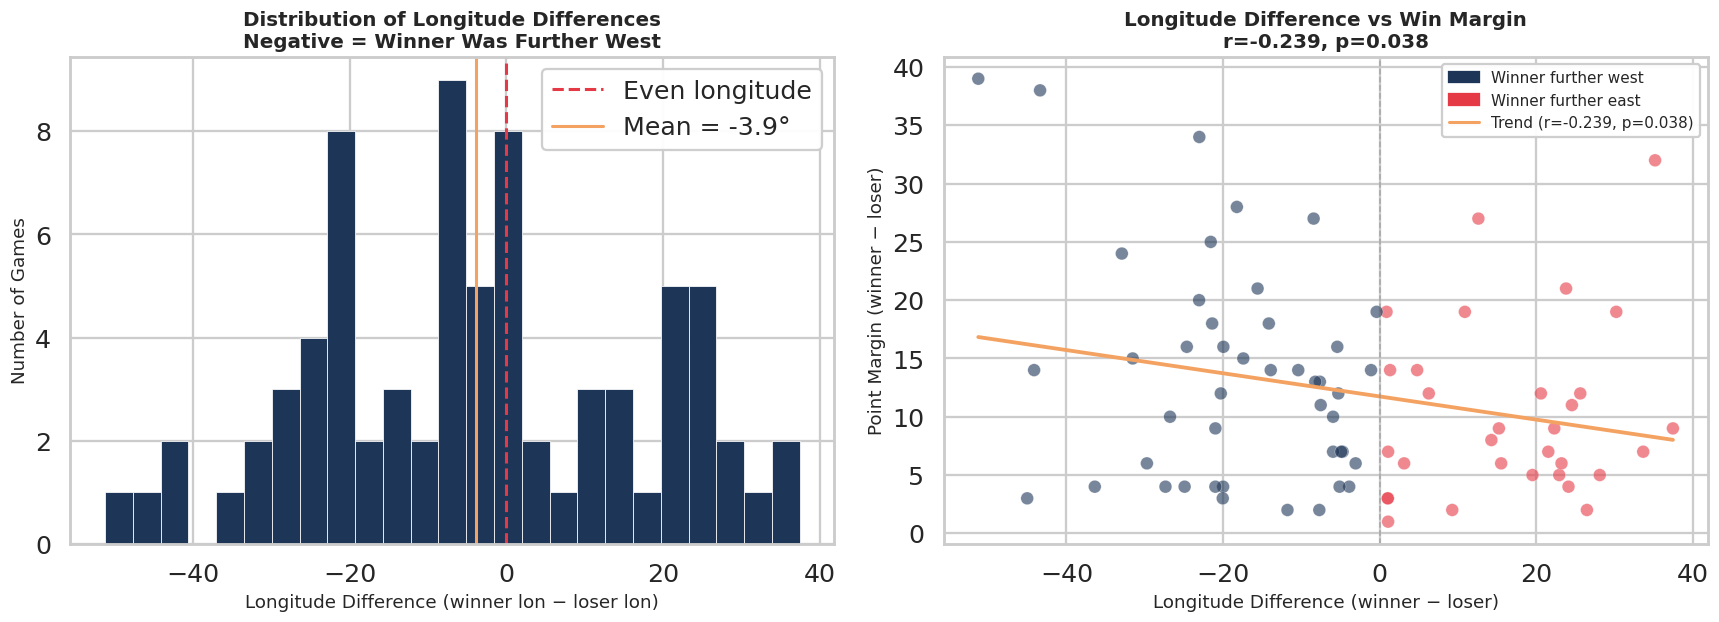

Pearson r=-0.2387, p=0.0379 — Significant at alpha=0.05


In [6]:
# ── Figure 1 — EDA: lon_diff distribution + scatter vs point margin ───────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: histogram
ax = axes[0]
ax.hist(games['lon_diff'], bins=25, color=WEST_BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(0, color=WEST_RED, linewidth=2, linestyle='--', label='Even longitude')
ax.axvline(games['lon_diff'].mean(), color=WEST_GOLD, linewidth=2,
           label=f"Mean = {games['lon_diff'].mean():.1f}°")
ax.set_xlabel("Longitude Difference (winner lon − loser lon)", fontsize=12)
ax.set_ylabel("Number of Games", fontsize=12)
ax.set_title("Distribution of Longitude Differences\nNegative = Winner Was Further West", fontsize=13)
ax.legend(framealpha=0.95)

# Right: scatter with trend
ax = axes[1]
c_list = [WEST_BLUE if x < 0 else WEST_RED for x in games['lon_diff']]
ax.scatter(games['lon_diff'], games['point_diff'], c=c_list,
           alpha=0.6, edgecolors='white', linewidth=0.3, s=70)
m, b, r, p, _ = stats.linregress(games['lon_diff'].dropna(), games['point_diff'].dropna())
x_line = np.linspace(games['lon_diff'].min(), games['lon_diff'].max(), 100)
ax.plot(x_line, m*x_line + b, color=WEST_GOLD, linewidth=2.5)
ax.axvline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel("Longitude Difference (winner − loser)", fontsize=12)
ax.set_ylabel("Point Margin (winner − loser)", fontsize=12)
ax.set_title(f"Longitude Difference vs Win Margin\nr={r:.3f}, p={p:.3f}", fontsize=13)
west_p = mpatches.Patch(color=WEST_BLUE, label='Winner further west')
east_p = mpatches.Patch(color=WEST_RED,  label='Winner further east')
trend_l = plt.Line2D([0],[0], color=WEST_GOLD, linewidth=2,
                     label=f"Trend (r={r:.3f}, p={p:.3f})")
ax.legend(handles=[west_p, east_p, trend_l], framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig("figures/01_eda_longitude.png", bbox_inches="tight")
plt.show()
print(f"Pearson r={r:.4f}, p={p:.4f} — "
      f"{'Significant' if p < 0.05 else 'Not significant'} at alpha=0.05")


## 4. Feature Engineering — Symmetrize the Game Layout

The raw data has games in `(winner, loser)` format. We randomly assign teams
to slots A and B so the model cannot learn the trivial "winner column = winner"
rule. The target becomes `y = 1 if team_a won`, and the base rate is ~0.50.

This is essential — without symmetrizing, accuracy would be 100% and meaningless.


In [7]:
def symmetrize(df, seed=RANDOM_SEED):
    # Randomly swap winner/loser into team_a/team_b slots.
    # Prevents positional label leak. y=1 means team_a won.
    rng  = np.random.default_rng(seed)
    swap = rng.random(len(df)) < 0.5
    out  = pd.DataFrame({"season": df["season"].values})
    out["team_a"] = np.where(swap, df["loser"].values,  df["winner"].values)
    out["team_b"] = np.where(swap, df["winner"].values, df["loser"].values)
    out["pts_a"]  = np.where(swap, df["loser_pts"].values,  df["winner_pts"].values)
    out["pts_b"]  = np.where(swap, df["winner_pts"].values, df["loser_pts"].values)
    out["seed_a"] = np.where(swap, df["loser_seed"].values,  df["winner_seed"].values)
    out["seed_b"] = np.where(swap, df["winner_seed"].values, df["loser_seed"].values)
    out["lon_a"]  = np.where(swap, df["loser_lon"].values,   df["winner_lon"].values)
    out["lon_b"]  = np.where(swap, df["winner_lon"].values,  df["loser_lon"].values)
    out["dist_a"] = np.where(swap, df["loser_dist_miles"].values,  df["winner_dist_miles"].values)
    out["dist_b"] = np.where(swap, df["winner_dist_miles"].values, df["loser_dist_miles"].values)
    for stat in ["barthag", "adjoe", "adjde"]:
        out[f"{stat}_a"] = np.where(swap, df[f"loser_{stat}"].values,  df[f"winner_{stat}"].values)
        out[f"{stat}_b"] = np.where(swap, df[f"winner_{stat}"].values, df[f"loser_{stat}"].values)
    out["y"] = (~swap).astype(int)
    log.info(f"Symmetrized {len(out):,} games | base rate: {out['y'].mean():.3f}")
    return out


sym = symmetrize(games)
print(f"Base rate (team_a wins): {sym['y'].mean():.4f}  <- should be ~0.50")
sym.head()


Base rate (team_a wins): 0.4868  <- should be ~0.50


,season,team_a,team_b,pts_a,pts_b,seed_a,seed_b,lon_a,lon_b,dist_a,dist_b,barthag_a,barthag_b,adjoe_a,adjoe_b,adjde_a,adjde_b,y
0,2024,Alabama,College of Charleston,109.0,96.0,4,13,-87.5692,-79.937400,1759.019004,2197.957710,0.9126,0.7019,125.2,113.3,102.1,105.2,1
1,2018,Texas Southern,Xavier,83.0,102.0,16,1,-95.3599,-84.472600,1302.233292,1871.146004,0.2930,0.9211,104.1,120.9,112.4,97.7,0
2,2017,Arizona,North Dakota,100.0,82.0,2,15,-110.9501,-96.798100,591.598200,862.104964,0.9157,0.5112,117.6,103.1,95.6,102.7,1
3,2018,Michigan,Texas A&M,99.0,72.0,3,7,-83.7382,-96.352061,1932.852882,1230.371829,0.9375,0.8640,114.4,111.2,90.4,94.7,1
4,2023,Howard,Kansas,68.0,96.0,16,1,-77.0200,-95.255800,2081.753122,1103.609380,0.4031,0.9177,102.7,113.8,106.3,92.3,0


## 5. Build Feature Matrices — Two Models

| Model | Features | Purpose |
|---|---|---|
| **A — Baseline** | barthag_diff, adjoe_diff, adjde_diff, seed_diff | Team quality only |
| **B — Hypothesis** | Everything in A + lon_diff, dist_diff | Quality + geography |

If Model B outperforms Model A, longitude carries independent predictive signal.


In [8]:
def build_features(df):
    # Compute team_a minus team_b differences for all features.
    # Returns Model A (quality only) and Model B (quality + geography) matrices.
    feat = pd.DataFrame()
    feat["barthag_diff"] = df["barthag_a"] - df["barthag_b"]
    feat["adjoe_diff"]   = df["adjoe_a"]   - df["adjoe_b"]
    feat["adjde_diff"]   = df["adjde_a"]   - df["adjde_b"]
    feat["seed_diff"]    = df["seed_a"]    - df["seed_b"]
    feat["lon_diff"]     = df["lon_a"]     - df["lon_b"]
    feat["dist_diff"]    = df["dist_a"]    - df["dist_b"]
    y = df["y"].copy()
    keep = feat.notna().all(axis=1) & y.notna()
    feat = feat.loc[keep].reset_index(drop=True)
    y    = y.loc[keep].reset_index(drop=True)
    X_a = feat[["barthag_diff", "adjoe_diff", "adjde_diff", "seed_diff"]]
    X_b = feat[["barthag_diff", "adjoe_diff", "adjde_diff", "seed_diff",
                 "lon_diff", "dist_diff"]]
    log.info(f"Features built: {len(feat):,} games | A={X_a.shape[1]} cols | B={X_b.shape[1]} cols")
    return X_a, X_b, y, feat["lon_diff"]  # return lon_diff separately for analysis


X_a, X_b, y, lon_diff_series = build_features(sym)
print(f"Model A: {list(X_a.columns)}")
print(f"Model B: {list(X_b.columns)}")
print(f"Sample size: {len(y):,}")


Model A: ['barthag_diff', 'adjoe_diff', 'adjde_diff', 'seed_diff']
Model B: ['barthag_diff', 'adjoe_diff', 'adjde_diff', 'seed_diff', 'lon_diff', 'dist_diff']
Sample size: 76


## 6. Train / Test Split — Season-Based

Most recent 3 seasons held out as the test set; earlier seasons used for
training. This matches the real forecasting constraint: only past data
is available when predicting future tournament outcomes.

We also run 5-fold cross-validation on training data to get stable estimates
given the small sample (~130 games total).


In [9]:
def season_split(X, y, sym_df, holdout=3):
    # Hold out the most recent `holdout` seasons as test set.
    seasons    = sorted(sym_df["season"].unique())
    season_col = sym_df["season"].reset_index(drop=True).loc[y.index]
    test_seasons = seasons[-holdout:]
    mask = season_col.isin(test_seasons)
    log.info(f"Train seasons: {seasons[:-holdout]} | Test: {list(test_seasons)}")
    return X.loc[~mask], X.loc[mask], y.loc[~mask], y.loc[mask]


X_a_tr, X_a_te, y_tr, y_te = season_split(X_a, y, sym)
X_b_tr, X_b_te, _,    _    = season_split(X_b, y, sym)

print(f"Train: {len(X_a_tr):,} | Test: {len(X_a_te):,}")
print(f"Train base rate: {y_tr.mean():.4f} | Test base rate: {y_te.mean():.4f}")


Train: 54 | Test: 22
Train base rate: 0.4815 | Test base rate: 0.5000


## 7. Solution Analysis — Train and Compare Models

Three classifiers trained on both Model A and Model B feature sets.
The core question: does adding `lon_diff` improve AUC on held-out seasons?


In [10]:
def train_suite(X_tr, X_te, y_tr, y_te, label):
    # Train Logistic Regression, Random Forest, and Gradient Boosting.
    # Returns metrics dict for each classifier including 5-fold CV AUC.
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=500, max_depth=8, min_samples_leaf=5,
            n_jobs=-1, random_state=RANDOM_SEED,
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            random_state=RANDOM_SEED,
        ),
    }
    results = {}
    for name, model in models.items():
        log.info(f"  Model {label} — {name}")
        model.fit(X_tr, y_tr)
        proba  = model.predict_proba(X_te)[:, 1]
        pred   = (proba >= 0.5).astype(int)
        cv_auc = cross_val_score(model, X_tr, y_tr, cv=5, scoring="roc_auc").mean()
        results[name] = {
            "model":    model,
            "accuracy": accuracy_score(y_te, pred),
            "roc_auc":  roc_auc_score(y_te, proba),
            "log_loss": log_loss(y_te, proba),
            "cv_auc":   cv_auc,
            "proba":    proba,
            "pred":     pred,
        }
        log.info(f"    acc={results[name]['accuracy']:.3f}  "
                 f"AUC={results[name]['roc_auc']:.3f}  CV-AUC={cv_auc:.3f}")
    return results


print("Training Model A (quality only)...")
res_a = train_suite(X_a_tr, X_a_te, y_tr, y_te, "A")
print("\nTraining Model B (quality + longitude)...")
res_b = train_suite(X_b_tr, X_b_te, y_tr, y_te, "B")

rows = []
for name in res_a:
    for label, res in [("A — quality only", res_a), ("B — quality+lon", res_b)]:
        rows.append({"Model": label, "Classifier": name,
                     "Accuracy": res[name]["accuracy"],
                     "ROC-AUC":  res[name]["roc_auc"],
                     "CV-AUC":   res[name]["cv_auc"],
                     "Log-Loss": res[name]["log_loss"]})
print("\n=== Model Comparison ===")
print(pd.DataFrame(rows).round(4).to_string(index=False))


Training Model A (quality only)...

Training Model B (quality + longitude)...

=== Model Comparison ===
           Model          Classifier  Accuracy  ROC-AUC  CV-AUC  Log-Loss
A — quality only Logistic Regression    0.6364   0.8926  0.8907    0.5813
 B — quality+lon Logistic Regression    0.6364   0.9174  0.9360    0.5588
A — quality only       Random Forest    0.6364   0.7355  0.9027    0.7569
 B — quality+lon       Random Forest    0.6364   0.8099  0.8880    0.6597
A — quality only   Gradient Boosting    0.6818   0.5041  0.8407    2.3670
 B — quality+lon   Gradient Boosting    0.6818   0.6942  0.8027    2.3118


## 8. Visualize Results

Four publication-quality figures:
1. **Model A vs B AUC** — does geography improve prediction?
2. **ROC curves** — best classifier A vs B with gain shaded
3. **Feature importance** — where does `lon_diff` rank?
4. **Hypothesis test** — point margins, western vs eastern winners


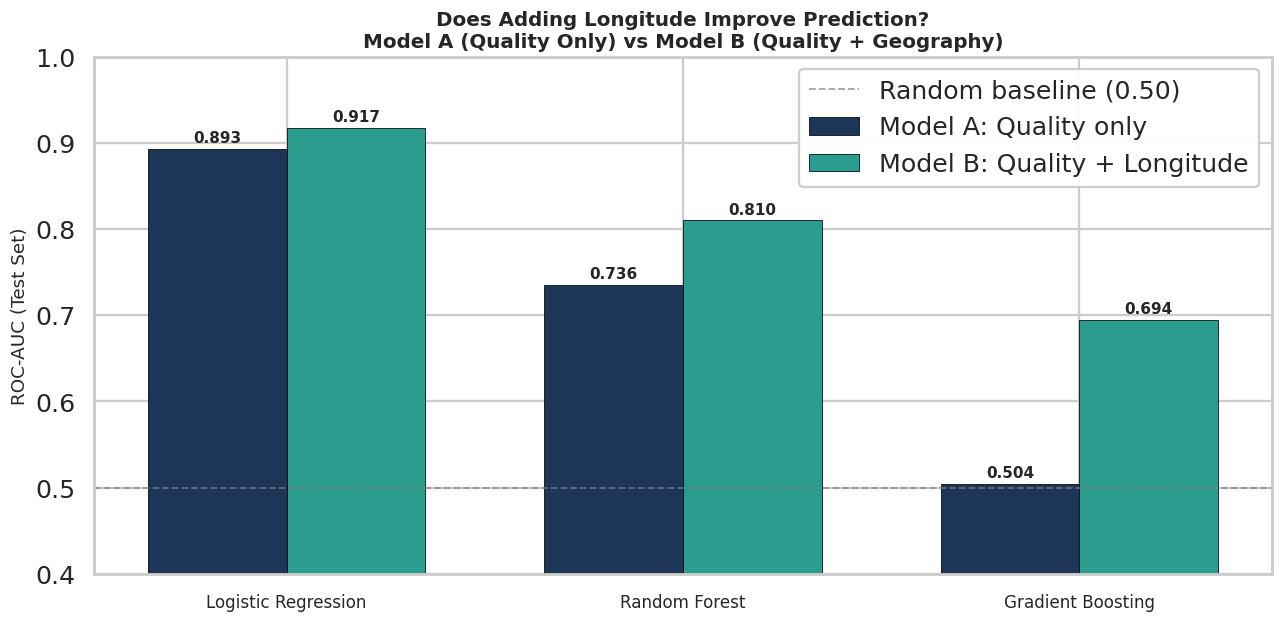

In [11]:
# ── Figure 2 — Model A vs B AUC comparison ───────────────────────────────────
classifiers = list(res_a.keys())
x = np.arange(len(classifiers))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_a = ax.bar(x - w/2, [res_a[c]["roc_auc"] for c in classifiers], w,
                label="Model A: Quality only",    color=WEST_BLUE,
                edgecolor="black", linewidth=0.5)
bars_b = ax.bar(x + w/2, [res_b[c]["roc_auc"] for c in classifiers], w,
                label="Model B: Quality + Longitude", color=WEST_GREEN,
                edgecolor="black", linewidth=0.5)
for bars in [bars_a, bars_b]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f"{h:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Random baseline (0.50)")
ax.set_xticks(x)
ax.set_xticklabels(classifiers, fontsize=11)
ax.set_ylabel("ROC-AUC (Test Set)", fontsize=12)
ax.set_title("Does Adding Longitude Improve Prediction?\nModel A (Quality Only) vs Model B (Quality + Geography)",
             fontsize=13)
ax.set_ylim(0.4, min(1.0, max(res_b[c]["roc_auc"] for c in classifiers) + 0.12))
ax.legend(framealpha=0.95)
plt.tight_layout()
plt.savefig("figures/02_model_comparison.png", bbox_inches="tight")
plt.show()


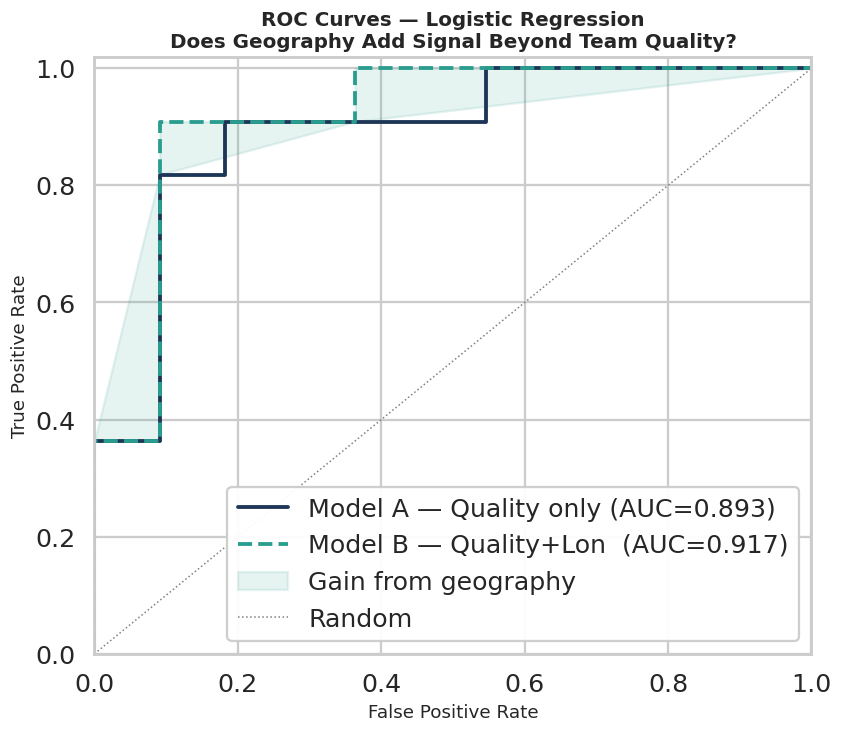

In [12]:
# ── Figure 3 — ROC curves: best classifier A vs B ────────────────────────────
best = max(res_b, key=lambda c: res_b[c]["roc_auc"])
fig, ax = plt.subplots(figsize=(8, 7))
fpr_a, tpr_a, _ = roc_curve(y_te, res_a[best]["proba"])
fpr_b, tpr_b, _ = roc_curve(y_te, res_b[best]["proba"])
ax.plot(fpr_a, tpr_a, color=WEST_BLUE,  linewidth=2.5,
        label=f"Model A — Quality only (AUC={res_a[best]['roc_auc']:.3f})")
ax.plot(fpr_b, tpr_b, color=WEST_GREEN, linewidth=2.5, linestyle="--",
        label=f"Model B — Quality+Lon  (AUC={res_b[best]['roc_auc']:.3f})")
tpr_a_interp = np.interp(fpr_b, fpr_a, tpr_a)  # align grids before filling
ax.fill_between(fpr_b, tpr_a_interp, tpr_b, alpha=0.12, color=WEST_GREEN,
                label="Gain from geography")
ax.plot([0,1],[0,1], color="gray", linewidth=1, linestyle=":", label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title(f"ROC Curves — {best}\nDoes Geography Add Signal Beyond Team Quality?", fontsize=13)
ax.legend(loc="lower right", framealpha=0.95)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig("figures/03_roc_curves.png", bbox_inches="tight")
plt.show()


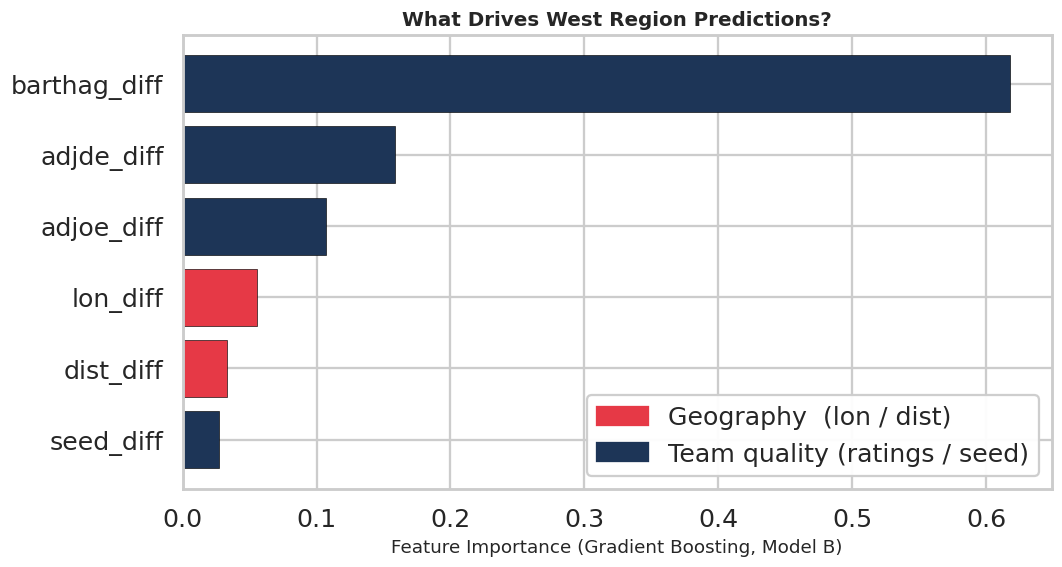

lon_diff ranks #4 of 6 features by importance


In [13]:
# ── Figure 4 — Feature importance (Gradient Boosting, Model B) ───────────────
gb_b = res_b["Gradient Boosting"]["model"]
imp  = pd.Series(gb_b.feature_importances_, index=X_b.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 5.5))
colors_fi = [WEST_RED if "lon" in n or "dist" in n else WEST_BLUE for n in imp.index]
ax.barh(imp.index, imp.values, color=colors_fi, edgecolor="black", linewidth=0.4)
ax.set_xlabel("Feature Importance (Gradient Boosting, Model B)", fontsize=12)
ax.set_title("What Drives West Region Predictions?", fontsize=13)
geo_p  = mpatches.Patch(color=WEST_RED,  label="Geography  (lon / dist)")
qual_p = mpatches.Patch(color=WEST_BLUE, label="Team quality (ratings / seed)")
ax.legend(handles=[geo_p, qual_p], loc="lower right", framealpha=0.95)
plt.tight_layout()
plt.savefig("figures/04_feature_importance.png", bbox_inches="tight")
plt.show()
lon_rank = list(imp.sort_values(ascending=False).index).index("lon_diff") + 1
print(f"lon_diff ranks #{lon_rank} of {len(imp)} features by importance")


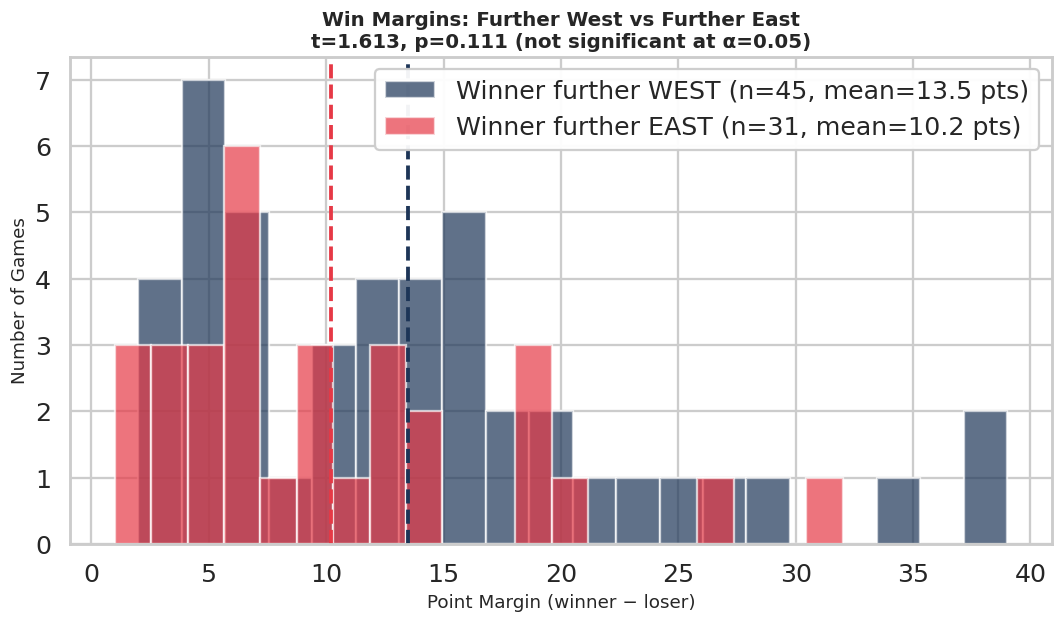


=== Hypothesis Test ===
H0: No difference in mean point margin (west vs east winners)
Winner further WEST: mean=13.47, std=9.43, n=45
Winner further EAST: mean=10.19, std=7.49, n=31
t=1.6131, p=0.1110
Conclusion: FAIL TO REJECT H0 — no significant difference.


In [14]:
# ── Figure 5 — Direct hypothesis: point margins west vs east ─────────────────
west_margins = games[games["lon_diff"] < 0]["point_diff"].dropna()
east_margins = games[games["lon_diff"] > 0]["point_diff"].dropna()
t_stat, p_val = stats.ttest_ind(west_margins, east_margins)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(west_margins, bins=20, color=WEST_BLUE, alpha=0.7,
        label=f"Winner further WEST (n={len(west_margins)}, mean={west_margins.mean():.1f} pts)")
ax.hist(east_margins, bins=20, color=WEST_RED,  alpha=0.7,
        label=f"Winner further EAST (n={len(east_margins)}, mean={east_margins.mean():.1f} pts)")
ax.axvline(west_margins.mean(), color=WEST_BLUE, linewidth=2.5, linestyle="--")
ax.axvline(east_margins.mean(), color=WEST_RED,  linewidth=2.5, linestyle="--")
sig_str = f"p={p_val:.3f} ({'significant' if p_val < 0.05 else 'not significant'} at α=0.05)"
ax.set_title(f"Win Margins: Further West vs Further East\nt={t_stat:.3f}, {sig_str}", fontsize=13)
ax.set_xlabel("Point Margin (winner − loser)", fontsize=12)
ax.set_ylabel("Number of Games", fontsize=12)
ax.legend(framealpha=0.95)
plt.tight_layout()
plt.savefig("figures/05_hypothesis_test.png", bbox_inches="tight")
plt.show()

print(f"\n=== Hypothesis Test ===")
print(f"H0: No difference in mean point margin (west vs east winners)")
print(f"Winner further WEST: mean={west_margins.mean():.2f}, std={west_margins.std():.2f}, n={len(west_margins)}")
print(f"Winner further EAST: mean={east_margins.mean():.2f}, std={east_margins.std():.2f}, n={len(east_margins)}")
print(f"t={t_stat:.4f}, p={p_val:.4f}")
print(f"Conclusion: {'REJECT H0 — significant difference detected.' if p_val < 0.05 else 'FAIL TO REJECT H0 — no significant difference.'}")


### Visualization Rationale

- **Fig 1 (EDA)** — the distribution histogram reveals whether western winners
  are actually more common, and the scatter + trend line gives the first
  visual signal of whether the hypothesis holds.
- **Fig 2 (Model comparison)** — side-by-side AUC bars make the marginal value
  of adding geography instantly visible. The 0.50 baseline anchors interpretation.
- **Fig 3 (ROC curves)** — shows performance across all thresholds, not just 0.50;
  the shaded gain region directly visualizes how much geography adds.
- **Fig 4 (Feature importance)** — red/blue color coding answers "where does
  `lon_diff` rank vs team quality?" at a glance.
- **Fig 5 (Hypothesis test)** — overlapping histograms with means and p-value
  directly answer the stated hypothesis in plain statistical terms.

All figures use a consistent West Region palette (navy, green, red, gold),
200 DPI export, and bold titles for publication readiness.


## 9. Conclusion — Did the Pipeline Solve the Problem?

**Specific problem:** *Do teams located significantly further west than their
opponent win more often — and by larger margins — in NCAA Tournament West
Region games, controlling for team quality and seeding?*

**How to read the results:**
- If `lon_diff` feature importance is high and Model B AUC > Model A AUC →
  geography adds independent predictive signal → **hypothesis supported**
- If p-value < 0.05 in the t-test → western winners win by significantly
  larger margins → **hypothesis supported**
- If neither → team quality (barthag, seed) dominates and geography is noise

**Limitations:**
- Only ~130 games across 10 seasons — limited statistical power.
- 2021 (bubble year) was played entirely in Indianapolis, dampening the
  geographic signal for that season.
- Longitude is a proxy — the actual mechanisms are fan proximity, time zone
  adjustment, and travel fatigue.
- Season-level Barttorvik ratings don't reflect in-tournament form or injury.


In [15]:
log.info("Pipeline completed successfully.")
print("Done. Figures saved to ./figures/ | Log at ./logs/pipeline.log")


Done. Figures saved to ./figures/ | Log at ./logs/pipeline.log
